In [5]:
import numpy as np
import math
import matplotlib.pyplot as plt
import time
from scipy.stats import norm
import QuantLib as ql

## Interest Rates - HW1F

Initialise yield curve data (this is just an exampe):

In [ ]:
# Setup dates & calendar
todays_date = ql.Date(1, 11, 2025)
ql.Settings.instance().evaluationDate = todays_date
calendar = ql.TARGET()
day_count = ql.Thirty360(ql.Thirty360.BondBasis)

# Choose upward-sloping pillars (in years)
pillars_yrs = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])

# Example: continuously-compounded zero rates that slope up
zeros_cc = np.array([0.045, 0.046, 0.0475, 0.049, 0.050, 0.052,
                     0.053, 0.054, 0.055, 0.056, 0.057])

# Build pillar dates from years (months ≈ years*12)
pillar_dates = [todays_date] + [
    calendar.advance(todays_date, ql.Period(int(round(y*12)), ql.Months))
    for y in pillars_yrs
]

# Year fractions for the chosen day count
pillar_t = np.array([0.0] + [day_count.yearFraction(todays_date, d) for d in pillar_dates[1:]])

# Convert zeros (cc) to discount factors: P(0,T) = exp(-z(T)*T)
discounts = [1.0] + list(np.exp(-zeros_cc * pillars_yrs))

# Build the curve from discount factors (bypasses compounding conventions)
disc_curve = ql.DiscountCurve(pillar_dates, discounts, day_count, calendar)
disc_curve.enableExtrapolation()
spot_curve_handle = ql.YieldTermStructureHandle(disc_curve)

Plot yield curve:

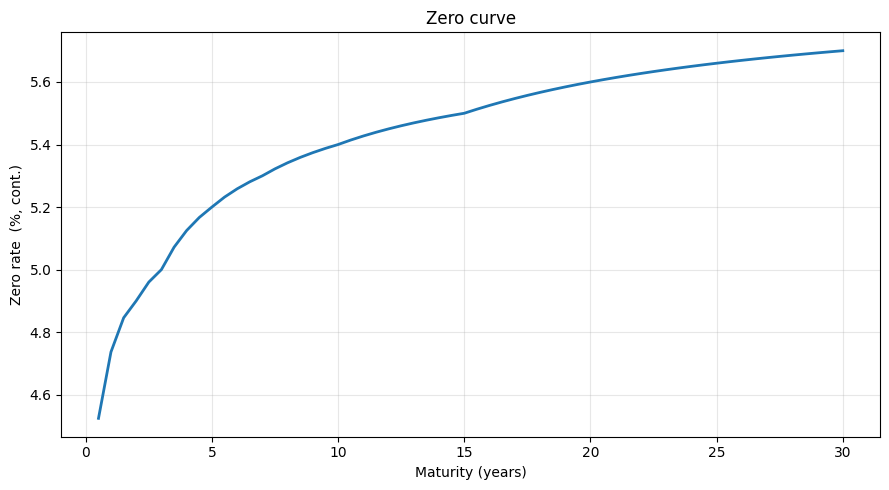

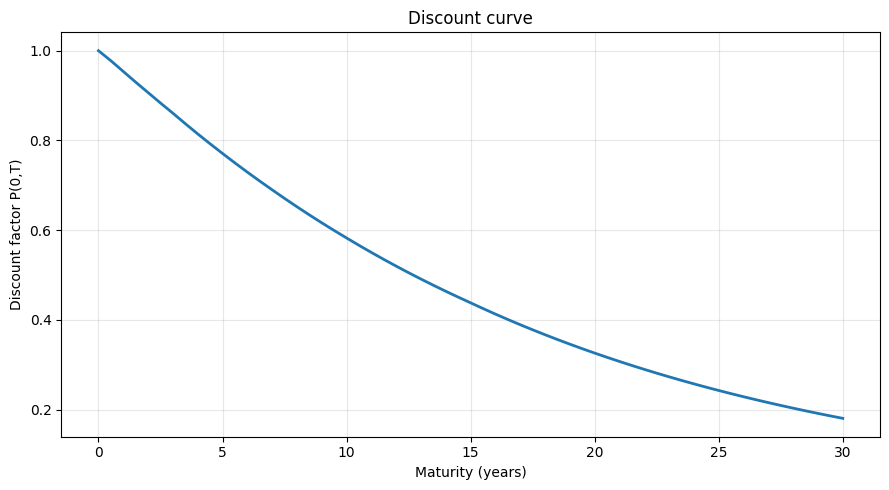

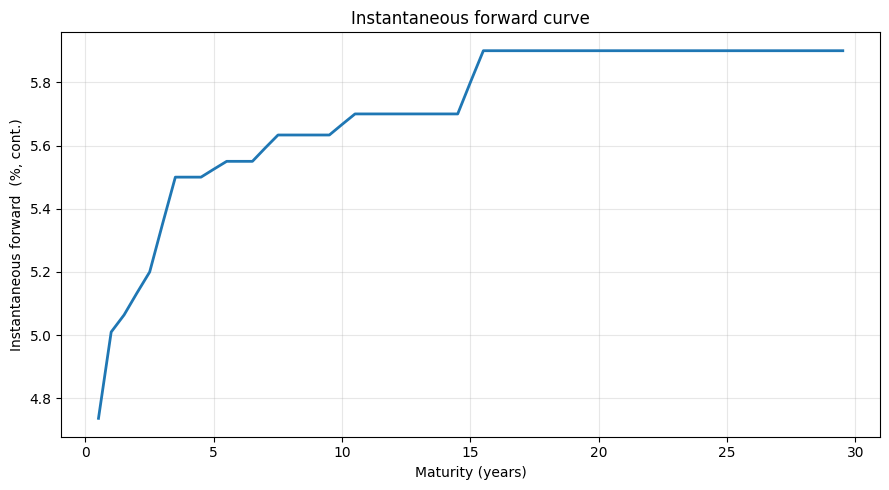

In [ ]:
def plot_yield_curve(curve_handle, todays_date, day_count, years=30, step_months=6, title_suffix=""):
    # sample dates on the curve
    calendar = ql.TARGET()
    dates = [todays_date] + [
        calendar.advance(todays_date, ql.Period(m, ql.Months))
        for m in range(step_months, years*12 + 1, step_months)
    ]

    # year fractions and discounts
    t = np.array([day_count.yearFraction(todays_date, d) for d in dates], dtype=float)
    P = np.array([curve_handle.discount(d) for d in dates], dtype=float)

    # continuous-compounded zero rates z(t) = -ln P(0,t) / t
    z = np.full_like(t, np.nan, dtype=float)
    z[1:] = -np.log(P[1:]) / t[1:]

    # (optional) instantaneous forwards via finite diff: f(t) ≈ -d/dt ln P(0,t)
    f = np.full_like(t, np.nan, dtype=float)
    lnP = np.log(P)
    if len(t) >= 3:
        f[1:-1] = -(lnP[2:] - lnP[:-2]) / (t[2:] - t[:-2])

    # plots
    plt.figure(figsize=(9,5))
    plt.plot(t, 100*z, lw=2)
    plt.xlabel("Maturity (years)"); plt.ylabel("Zero rate  (%, cont.)")
    plt.title(f"Zero curve{title_suffix}"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,5))
    plt.plot(t, P, lw=2)
    plt.xlabel("Maturity (years)"); plt.ylabel("Discount factor P(0,T)")
    plt.title(f"Discount curve{title_suffix}"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    # (optional) forwards
    if np.isfinite(f[1:-1]).any():
        plt.figure(figsize=(9,5))
        plt.plot(t, 100*f, lw=2)
        plt.xlabel("Maturity (years)"); plt.ylabel("Instantaneous forward  (%, cont.)")
        plt.title(f"Instantaneous forward curve{title_suffix}")
        plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


plot_yield_curve(spot_curve_handle, todays_date, day_count, years=30, step_months=6, title_suffix="")

Define process using QuantLib:

In [8]:
a, sigma = 0.1, 0.1
hw_process = ql.HullWhiteProcess(spot_curve_handle, a, sigma)

Simulation function:

In [9]:
def generate_paths(num_paths, timestep, seq):
    arr = np.zeros((num_paths, timestep+1))
    # time grid is same for every path
    path = seq.next().value()
    time = np.array([path.time(j) for j in range(len(path))])
    arr[0, :] = np.array([path[j] for j in range(len(path))])
    for i in range(1, num_paths):
        path = seq.next().value()
        arr[i, :] = np.array([path[j] for j in range(len(path))])
    return time, arr

Simulate rates:

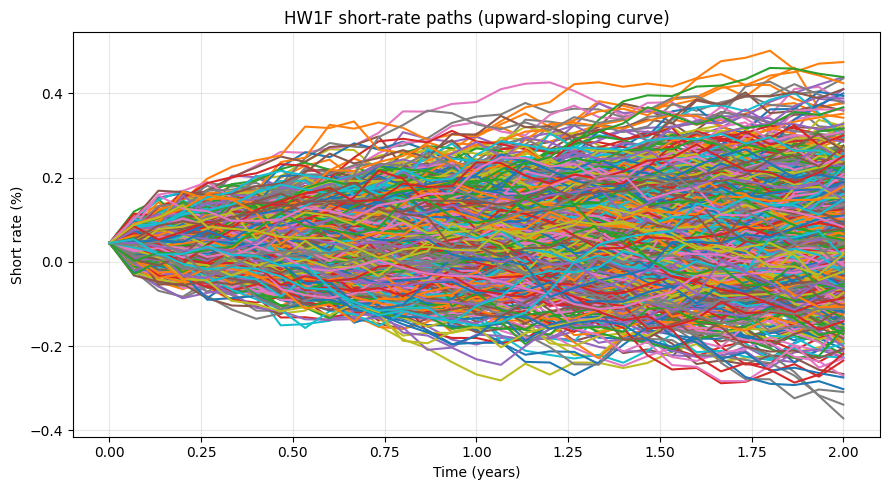

In [15]:
timestep = 30
length = 2.0  # years
urng = ql.UniformRandomSequenceGenerator(timestep, ql.UniformRandomGenerator(12345))
grng = ql.GaussianRandomSequenceGenerator(urng)
seq = ql.GaussianPathGenerator(hw_process, length, timestep, grng, False)

# Simulate and plot
num_paths = 1000
time, paths = generate_paths(num_paths, timestep, seq)
plt.figure(figsize=(9,5))
plt.plot(time, paths.T)
plt.xlabel("Time (years)"); plt.ylabel("Short rate (%)"); plt.title("HW1F short-rate paths (upward-sloping curve)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Equity Prices - GBM

Parameters:

In [11]:
s_start = 100
r = 0.05
sigma = 0.2 
T_sim = 1
n_sims = 10_000
m_steps = 250

Simulation Function:

In [12]:
def gbm_path_sim_vectorized(s_start, r, sigma, T_sim, n_sims, m_steps):
    """
    Simulates Geometric Brownian Motion paths using a vectorized numpy approach.
    
    s_start: Initial asset price (S_t)
    r: Risk-free interest rate
    sigma: Volatility
    T_sim: Time horizon for the simulation (e.g., T_remaining)
    n_sims: Number of simulation paths (N)
    m_steps: Number of time steps (M_remaining)
    """
    
    dt = T_sim / m_steps
    
    # 1. Create a matrix of all random numbers at once
    # Shape: (n_sims, m_steps)
    Z = np.random.normal(0.0, 1.0, (n_sims, m_steps))
    
    # 2. Calculate all log-returns in one go
    # Shape: (n_sims, m_steps)
    log_returns = (r - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z
    
    # 3. Calculate the cumulative sum of log-returns across time (axis=1)
    # Shape: (n_sims, m_steps)
    # The result at [i, j] is the sum of log-returns from 0 to j for path i
    cumulative_log_returns = np.cumsum(log_returns, axis=1)
    
    # 4. Create the output matrix and set the start price
    # Shape: (n_sims, m_steps + 1)
    simulated_paths = np.zeros((n_sims, m_steps + 1))
    simulated_paths[:, 0] = s_start
    
    # 5. Exponentiate and multiply by s_start to get all prices from t=1 to t=M
    # This fills all columns from index 1 onwards
    simulated_paths[:, 1:] = s_start * np.exp(cumulative_log_returns)
            
    # Return the complete matrix of paths
    return simulated_paths

Simulate and plot

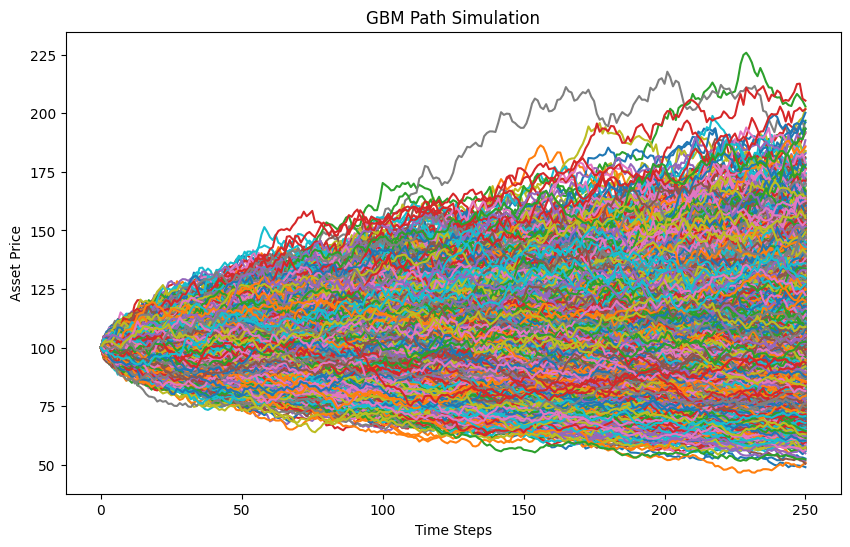

In [13]:
gbm_paths = gbm_path_sim_vectorized(s_start=s_start, r=r, sigma=sigma, T_sim=T_sim, n_sims=n_sims, m_steps=m_steps)
plt.figure(figsize=(10, 6))

# Plot
plt.plot(gbm_paths.T) 

# Add labels and show the plot
plt.title("GBM Path Simulation")
plt.xlabel("Time Steps")
plt.ylabel("Asset Price")
plt.show()